
# IFS-Visualisierungskonzept für Management / Vorstand

Dieses Notebook konkretisiert ein mögliches Berichtskonzept für einen IFS-Scan auf Basis von Dateimetadaten.

## Ziel
Aus technischen Dateiinformationen eine **managementtaugliche Übersicht** erzeugen:
- **Umfang** des Bestands
- **Speicherverteilung** nach Verzeichnissen
- **Dateimengen** je Bereich
- **Aktualität / Altersstruktur**
- **Dateitypen und Größenklassen**
- **Auffälligkeiten** (größte / älteste Dateien)

## Datengrundlage
Das Notebook arbeitet zunächst mit **Dummy-Daten**, die an Deine Spaltenstruktur angelehnt sind:

- `Name`
- `Path`
- `Type`
- `INode`
- `ID_Nbr`
- `nbrLinks`
- `UID`
- `GrID`
- `Size`
- `MRAcc_Tme`
- `MRMod_Tme`
- `MRCr_Tme`

## Hinweis für die Praxis
Sobald echte Scan-Daten vorliegen, muss im Abschnitt **"1) Dummy-Daten erzeugen"** nur die Dummy-Erzeugung durch das Einlesen Deiner CSV ersetzt werden, z. B.:

```python
df = pd.read_csv("dein_scan.csv", sep=";", encoding="utf-8")
```


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import PurePosixPath
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

rng = np.random.default_rng(42)


## 1) Dummy-Daten erzeugen

In [2]:

root_dirs = {
    "/ifs/finance": {
        "subdirs": ["reports", "exports", "archive", "monthly"],
        "weight": 0.20,
        "exts": [".csv", ".xlsx", ".pdf", ".txt"]
    },
    "/ifs/sales": {
        "subdirs": ["daily", "weekly", "archive", "broker"],
        "weight": 0.18,
        "exts": [".csv", ".xlsx", ".pdf", ".log"]
    },
    "/ifs/hr": {
        "subdirs": ["payroll", "archive", "contracts", "exports"],
        "weight": 0.10,
        "exts": [".pdf", ".csv", ".txt", ""]
    },
    "/ifs/logs": {
        "subdirs": ["batch", "jobs", "archive", "system"],
        "weight": 0.16,
        "exts": [".log", ".txt", ".csv", ""]
    },
    "/ifs/interfaces": {
        "subdirs": ["inbound", "outbound", "archive", "temp"],
        "weight": 0.14,
        "exts": [".csv", ".xml", ".json", ".txt"]
    },
    "/ifs/documents": {
        "subdirs": ["board", "policies", "archive", "manuals"],
        "weight": 0.12,
        "exts": [".pdf", ".docx", ".xlsx", ".pptx"]
    },
    "/ifs/projects": {
        "subdirs": ["legacy", "analysis", "archive", "deliverables"],
        "weight": 0.10,
        "exts": [".ipynb", ".py", ".csv", ".pdf"]
    },
}

n_files = 2500
root_choices = list(root_dirs.keys())
root_weights = np.array([root_dirs[k]["weight"] for k in root_choices], dtype=float)
root_weights = root_weights / root_weights.sum()

uids = [1001, 1002, 1003, 1100, 1200]
gids = [200, 210, 220, 230]
devices = [1, 2, 3]

def random_timestamp(days_back_low=0, days_back_high=3650):
    days_back = int(rng.integers(days_back_low, days_back_high))
    secs = int(rng.integers(0, 24*3600))
    ts = pd.Timestamp.now().floor("s") - pd.Timedelta(days=days_back, seconds=secs)
    return ts

rows = []
for i in range(n_files):
    root = rng.choice(root_choices, p=root_weights)
    subdir = rng.choice(root_dirs[root]["subdirs"])
    ext = rng.choice(root_dirs[root]["exts"])

    if root == "/ifs/logs":
        size_bytes = int(np.exp(rng.normal(11.0, 1.1)))
    elif root in ["/ifs/finance", "/ifs/sales"]:
        size_bytes = int(np.exp(rng.normal(13.5, 1.2)))
    elif root == "/ifs/documents":
        size_bytes = int(np.exp(rng.normal(14.0, 1.0)))
    else:
        size_bytes = int(np.exp(rng.normal(12.5, 1.3)))
    size_bytes = max(size_bytes, 512)

    if rng.random() < 0.01:
        size_bytes *= int(rng.integers(100, 500))

    mtime = random_timestamp(0, 3650)
    atime = mtime + pd.Timedelta(days=int(rng.integers(0, 120)))
    ctime = mtime - pd.Timedelta(days=int(rng.integers(0, 60)))

    name = f"file_{i:05d}{ext}"
    path = f"{root}/{subdir}/{name}"

    rows.append({
        "Name": name,
        "Path": path,
        "Type": int(rng.choice([33188, 33261, 33204])),
        "INode": int(rng.integers(10_000, 9_999_999)),
        "ID_Nbr": int(rng.choice(devices)),
        "nbrLinks": int(rng.choice([1, 1, 1, 2, 3])),
        "UID": int(rng.choice(uids)),
        "GrID": int(rng.choice(gids)),
        "Size": int(size_bytes),
        "MRAcc_Tme": atime,
        "MRMod_Tme": mtime,
        "MRCr_Tme": ctime,
    })

df = pd.DataFrame(rows)
df.head()


,Name,Path,Type,INode,ID_Nbr,nbrLinks,UID,GrID,Size,MRAcc_Tme,MRMod_Tme,MRCr_Tme
0,file_00000.xml,/ifs/interfaces/archive/file_00000.xml,33204,7613784,3,2,1003,200,711824,2024-05-21 17:18:02,2024-03-19 17:18:02,2024-01-21 17:18:02
1,file_00001.csv,/ifs/hr/contracts/file_00001.csv,33261,2280114,1,1,1200,200,737579,2022-05-20 23:48:52,2022-03-16 23:48:52,2022-02-18 23:48:52
2,file_00002.xlsx,/ifs/documents/policies/file_00002.xlsx,33204,7786050,3,1,1002,210,999627,2025-09-10 20:15:50,2025-07-19 20:15:50,2025-05-27 20:15:50
3,file_00003.csv,/ifs/finance/archive/file_00003.csv,33204,3710892,1,1,1100,200,1223205,2022-09-11 20:20:26,2022-07-24 20:20:26,2022-07-05 20:20:26
4,file_00004.xlsx,/ifs/finance/archive/file_00004.xlsx,33261,7005647,1,1,1100,230,271202,2016-11-18 09:04:09,2016-10-30 09:04:09,2016-09-11 09:04:09


In [4]:

df.to_csv(r"ifs_dummy_scan.csv", sep=";", encoding="utf-8", index=False)
print("CSV geschrieben nach:", r"/mnt/data/ifs_dummy_scan.csv")


CSV geschrieben nach: /mnt/data/ifs_dummy_scan.csv


## 2) Datenaufbereitung für Visualisierungen

In [5]:

for col in ["MRAcc_Tme", "MRMod_Tme", "MRCr_Tme"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

def get_root_dir(path: str) -> str:
    p = PurePosixPath(path)
    return "/" + "/".join(p.parts[1:3]) if len(p.parts) >= 3 else str(p)

def get_subdir(path: str) -> str:
    p = PurePosixPath(path)
    return "/" + "/".join(p.parts[1:4]) if len(p.parts) >= 4 else str(p)

def get_ext(name: str) -> str:
    suffix = PurePosixPath(name).suffix.lower()
    return suffix if suffix else "[ohne Endung]"

df["root_dir"] = df["Path"].map(get_root_dir)
df["sub_dir"] = df["Path"].map(get_subdir)
df["ext"] = df["Name"].map(get_ext)
df["size_mb"] = df["Size"] / (1024**2)
df["size_gb"] = df["Size"] / (1024**3)

today = pd.Timestamp.now().floor("D")
df["age_days"] = (today - df["MRMod_Tme"].dt.floor("D")).dt.days

bins = [-1, 30, 180, 365, 3*365, 10_000]
labels = ["<= 30 Tage", "31-180 Tage", "181-365 Tage", "1-3 Jahre", "> 3 Jahre"]
df["age_class"] = pd.cut(df["age_days"], bins=bins, labels=labels)

size_bins = [-1, 1, 10, 100, 1024, float("inf")]
size_labels = ["< 1 MB", "1-10 MB", "10-100 MB", "100 MB - 1 GB", "> 1 GB"]
df["size_class"] = pd.cut(df["size_mb"], bins=size_bins, labels=size_labels)

df.sample(5, random_state=42)


,Name,Path,Type,INode,ID_Nbr,nbrLinks,UID,GrID,Size,MRAcc_Tme,MRMod_Tme,MRCr_Tme,root_dir,sub_dir,ext,size_mb,size_gb,age_days,age_class,size_class
1447,file_01447.txt,/ifs/logs/jobs/file_01447.txt,33261,263986,1,1,1100,220,30605,2023-07-02 06:34:51,2023-03-09 06:34:51,2023-01-12 06:34:51,/ifs/logs,/ifs/logs/jobs,.txt,0.029187,0.000029,1111,> 3 Jahre,< 1 MB
1114,file_01114.pdf,/ifs/finance/exports/file_01114.pdf,33204,3886942,3,2,1003,230,430156,2021-12-21 15:24:31,2021-10-03 15:24:31,2021-10-03 15:24:31,/ifs/finance,/ifs/finance/exports,.pdf,0.410229,0.000401,1633,> 3 Jahre,< 1 MB
1064,file_01064.txt,/ifs/finance/exports/file_01064.txt,33188,2327909,3,3,1002,230,1394242,2022-12-11 15:13:42,2022-10-09 15:13:42,2022-08-25 15:13:42,/ifs/finance,/ifs/finance/exports,.txt,1.329653,0.001298,1262,> 3 Jahre,1-10 MB
2287,file_02287.pdf,/ifs/finance/archive/file_02287.pdf,33261,1461762,2,3,1100,210,21084,2024-05-31 01:22:30,2024-03-16 01:22:30,2024-01-26 01:22:30,/ifs/finance,/ifs/finance/archive,.pdf,0.020107,0.000020,738,1-3 Jahre,< 1 MB
1537,file_01537.txt,/ifs/logs/batch/file_01537.txt,33188,6948668,3,1,1003,210,31222,2024-08-22 00:49:33,2024-08-12 00:49:33,2024-07-24 00:49:33,/ifs/logs,/ifs/logs/batch,.txt,0.029776,0.000029,589,1-3 Jahre,< 1 MB


## 3) Executive Summary / KPI-Kacheln

In [6]:

kpis = {
    "Gesamtdateien": len(df),
    "Gesamtvolumen (GB)": round(df["size_gb"].sum(), 2),
    "Anzahl Hauptverzeichnisse": df["root_dir"].nunique(),
    "Größte Einzeldatei (MB)": round(df["size_mb"].max(), 2),
    "Anteil > 3 Jahre alt (%)": round((df["age_class"] == "> 3 Jahre").mean() * 100, 1),
    "Häufigste Endung": df["ext"].value_counts().idxmax(),
}

kpi_df = pd.DataFrame({"Kennzahl": list(kpis.keys()), "Wert": list(kpis.values())})
display(kpi_df)

summary_md = "\n".join([
    "### Management-Kernaussagen",
    f"- Es wurden **{kpis['Gesamtdateien']} Dateien** mit einem simulierten Gesamtvolumen von **{kpis['Gesamtvolumen (GB)']} GB** erfasst.",
    f"- Der Anteil älterer Dateien (**> 3 Jahre nicht geändert**) beträgt **{kpis['Anteil > 3 Jahre alt (%)']} %**.",
    f"- Die häufigste Dateiendung ist **{kpis['Häufigste Endung']}**."
])
display(Markdown(summary_md))


,Kennzahl,Wert
0,Gesamtdateien,2500
1,Gesamtvolumen (GB),10.15
2,Anzahl Hauptverzeichnisse,7
3,Größte Einzeldatei (MB),2499.35
4,Anteil > 3 Jahre alt (%),69.5
5,Häufigste Endung,.csv


### Management-Kernaussagen
- Es wurden **2500 Dateien** mit einem simulierten Gesamtvolumen von **10.15 GB** erfasst.
- Der Anteil älterer Dateien (**> 3 Jahre nicht geändert**) beträgt **69.5 %**.
- Die häufigste Dateiendung ist **.csv**.

## 4) Wichtigste Grafik: Speicherverbrauch nach Hauptverzeichnis

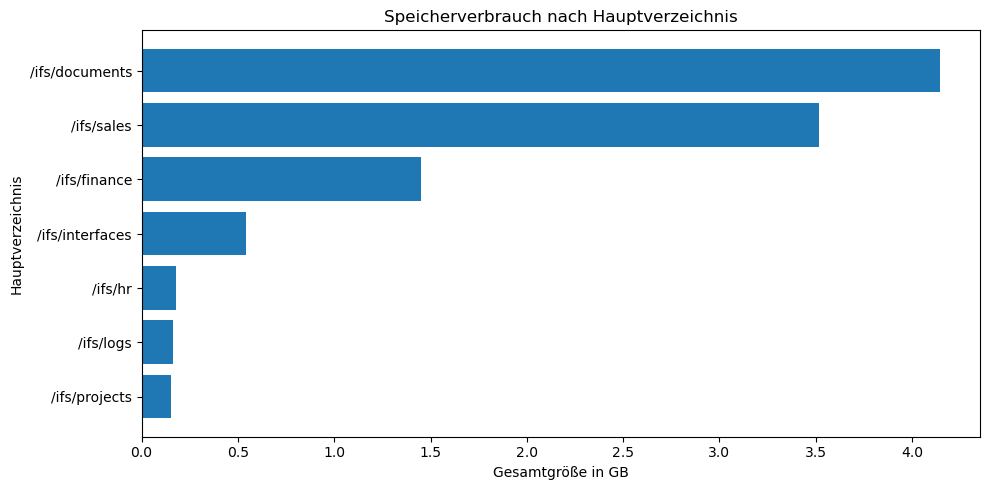

,root_dir,size_gb
0,/ifs/documents,4.146125
6,/ifs/sales,3.518334
1,/ifs/finance,1.451941
3,/ifs/interfaces,0.543155
2,/ifs/hr,0.178815
4,/ifs/logs,0.160267
5,/ifs/projects,0.154904


In [7]:

size_by_root = (
    df.groupby("root_dir", as_index=False)["size_gb"]
      .sum()
      .sort_values("size_gb", ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(size_by_root["root_dir"], size_by_root["size_gb"])
plt.xlabel("Gesamtgröße in GB")
plt.ylabel("Hauptverzeichnis")
plt.title("Speicherverbrauch nach Hauptverzeichnis")
plt.tight_layout()
plt.show()

display(size_by_root.sort_values("size_gb", ascending=False))



**Interpretation:**  
Diese Grafik beantwortet die Management-Frage: **Wo liegt der Speicherverbrauch?**  
Oft zeigt sich, dass wenige Verzeichnisse den Hauptanteil des IFS-Volumens tragen. Genau dort liegen dann mögliche Ansatzpunkte für Archivierung, Bereinigung oder Governance.


## 5) Dateianzahl nach Hauptverzeichnis

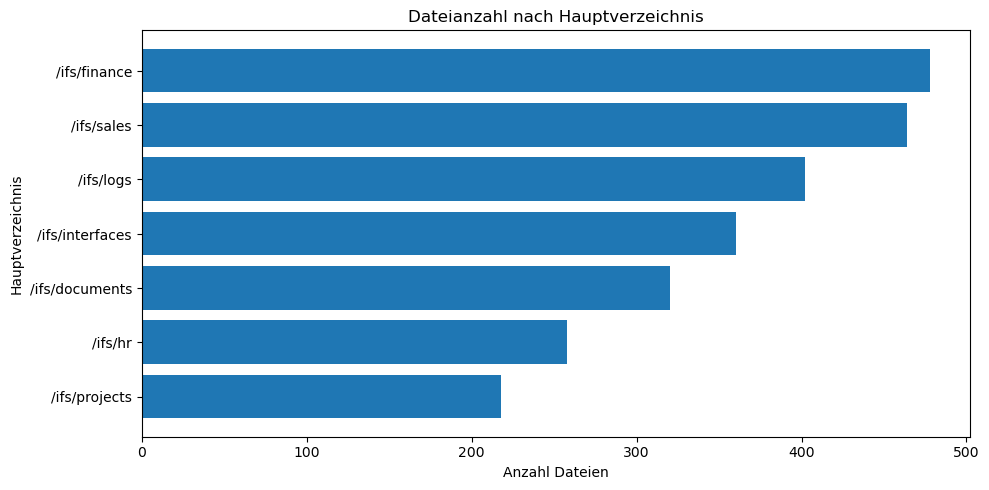

,root_dir,file_count
1,/ifs/finance,478
6,/ifs/sales,464
4,/ifs/logs,402
3,/ifs/interfaces,360
0,/ifs/documents,320
2,/ifs/hr,258
5,/ifs/projects,218


In [8]:

count_by_root = (
    df.groupby("root_dir", as_index=False)["Name"]
      .count()
      .rename(columns={"Name": "file_count"})
      .sort_values("file_count", ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(count_by_root["root_dir"], count_by_root["file_count"])
plt.xlabel("Anzahl Dateien")
plt.ylabel("Hauptverzeichnis")
plt.title("Dateianzahl nach Hauptverzeichnis")
plt.tight_layout()
plt.show()

display(count_by_root.sort_values("file_count", ascending=False))



**Interpretation:**  
Die Dateianzahl ergänzt die reine Volumensicht.  
Ein Verzeichnis kann entweder:
- **viele kleine Dateien** enthalten oder
- **wenige sehr große Dateien**.

Gerade diese Gegenüberstellung ist für Management-Entscheidungen wichtig.


## 6) Altersstruktur der Dateien nach Hauptverzeichnis

C:\Users\stefa\AppData\Local\Temp\ipykernel_24000\945452908.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="root_dir", columns="age_class", values="Name", aggfunc="count", fill_value=0)


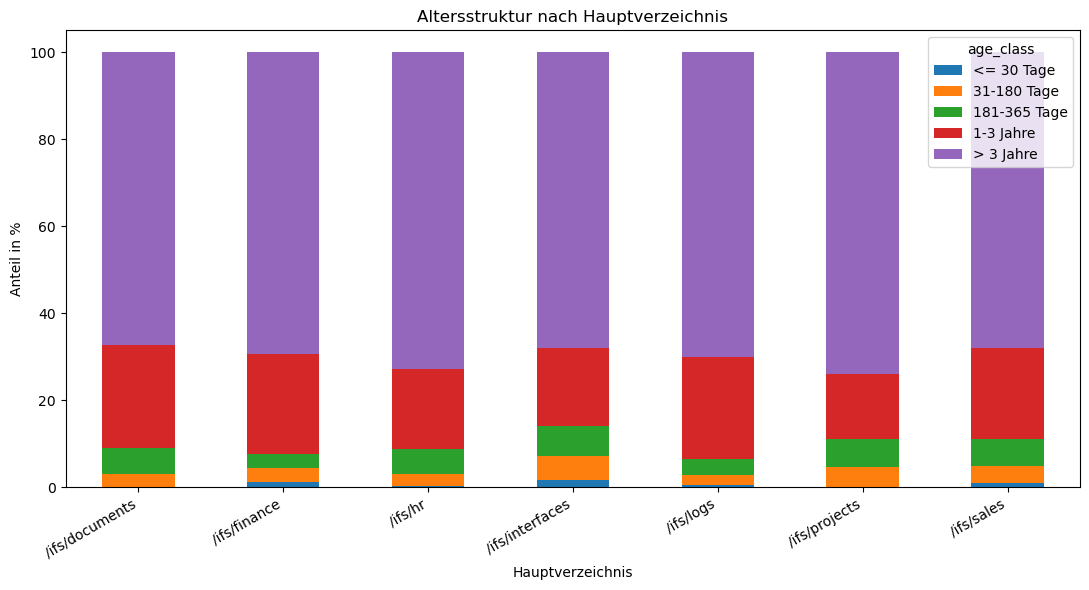

age_class,<= 30 Tage,31-180 Tage,181-365 Tage,1-3 Jahre,> 3 Jahre
root_dir,,,,,
/ifs/documents,0,10,19,76,215
/ifs/finance,6,15,16,110,331
/ifs/hr,1,7,15,47,188
/ifs/interfaces,6,20,25,64,245
/ifs/logs,2,9,15,94,282
/ifs/projects,0,10,14,33,161
/ifs/sales,5,18,29,97,315


In [9]:

labels = ["<= 30 Tage", "31-180 Tage", "181-365 Tage", "1-3 Jahre", "> 3 Jahre"]

age_pivot = (
    df.pivot_table(index="root_dir", columns="age_class", values="Name", aggfunc="count", fill_value=0)
      .reindex(columns=labels)
)

age_pivot_pct = age_pivot.div(age_pivot.sum(axis=1), axis=0) * 100

age_pivot_pct.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.ylabel("Anteil in %")
plt.xlabel("Hauptverzeichnis")
plt.title("Altersstruktur nach Hauptverzeichnis")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(age_pivot)



**Interpretation:**  
Diese Sicht zeigt, welche Bereiche **aktiv** sind und wo sich **Altbestände** konzentrieren.  
Für einen Vorstand ist das besonders nützlich, weil daraus unmittelbar fachliche Prüfaufträge abgeleitet werden können, etwa:
- Archivierungsfähigkeit prüfen
- Löschkonzepte überprüfen
- Verantwortlichkeiten für Altbestände klären


## 7) Dateitypen: Häufigkeit und Speicherverbrauch

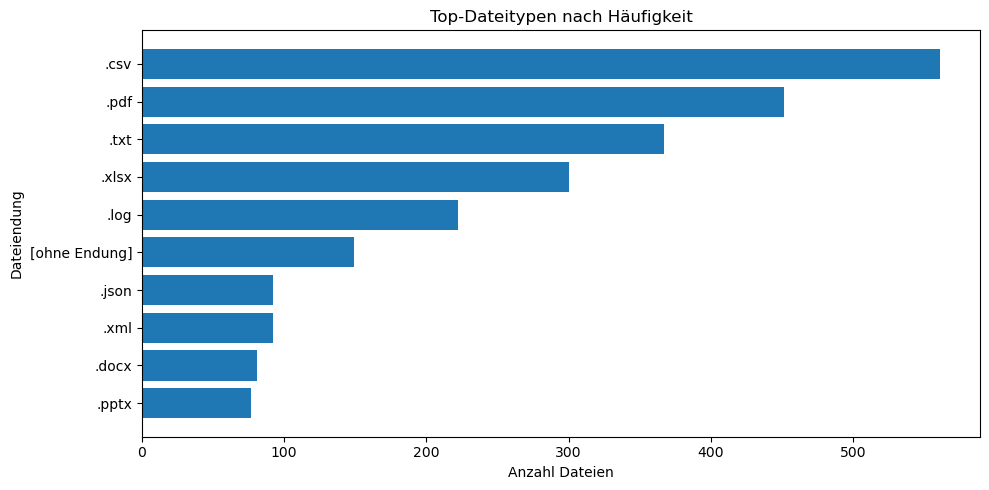

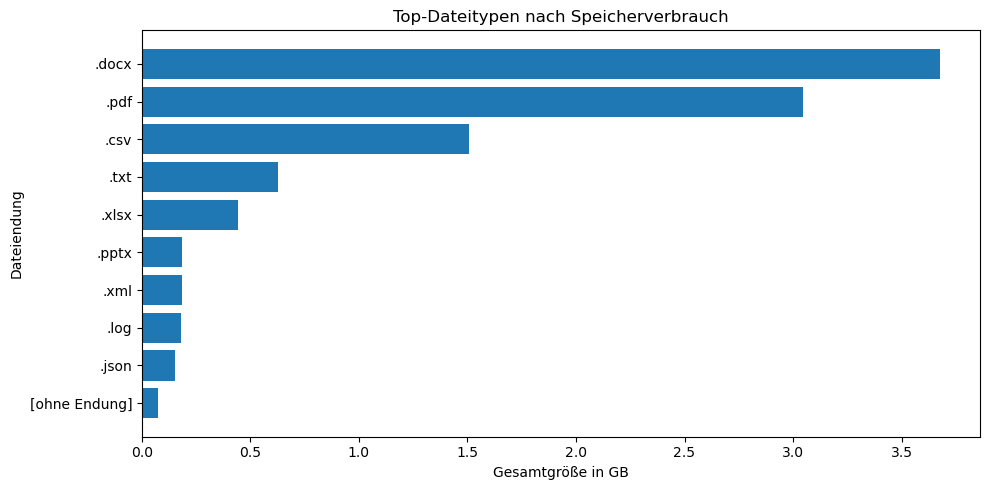

,count,size_gb
ext,,
.docx,81,3.677300
.pdf,451,3.044233
.csv,561,1.506493
.txt,367,0.628440
.xlsx,300,0.443778
.pptx,77,0.185385
.xml,92,0.185303
.log,222,0.179363
.json,92,0.153290


In [10]:

top_ext_count = df["ext"].value_counts().head(10).sort_values(ascending=True)
top_ext_size = (
    df.groupby("ext")["size_gb"].sum()
      .sort_values(ascending=True)
      .tail(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_ext_count.index, top_ext_count.values)
plt.xlabel("Anzahl Dateien")
plt.ylabel("Dateiendung")
plt.title("Top-Dateitypen nach Häufigkeit")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(top_ext_size.index, top_ext_size.values)
plt.xlabel("Gesamtgröße in GB")
plt.ylabel("Dateiendung")
plt.title("Top-Dateitypen nach Speicherverbrauch")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "count": df["ext"].value_counts(),
    "size_gb": df.groupby("ext")["size_gb"].sum()
}).sort_values(["size_gb", "count"], ascending=False).head(15))



**Interpretation:**  
Dateitypen helfen, den Bestand fachlich grob zu klassifizieren:
- Berichte / Office-Dateien
- Protokolle / Logs
- Schnittstellen- oder Exportdateien
- technische Artefakte
- Dateien ohne eindeutige Endung


## 8) Größenklassen der Dateien

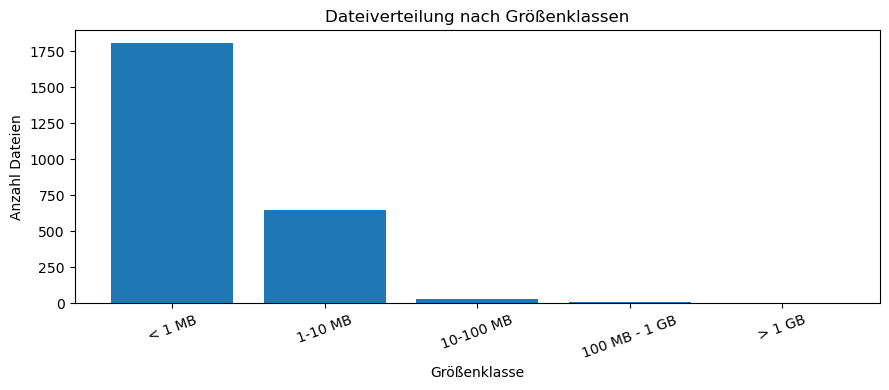

,Anzahl Dateien
size_class,
< 1 MB,1806
1-10 MB,649
10-100 MB,30
100 MB - 1 GB,13
> 1 GB,2


In [11]:

size_labels = ["< 1 MB", "1-10 MB", "10-100 MB", "100 MB - 1 GB", "> 1 GB"]
size_class_counts = df["size_class"].value_counts().reindex(size_labels)

plt.figure(figsize=(9, 4))
plt.bar(size_class_counts.index.astype(str), size_class_counts.values)
plt.xlabel("Größenklasse")
plt.ylabel("Anzahl Dateien")
plt.title("Dateiverteilung nach Größenklassen")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(size_class_counts.rename("Anzahl Dateien").to_frame())



**Interpretation:**  
Die Größenklassen zeigen, ob das IFS eher aus:
- vielen kleinen Dateien,
- einem gemischten Bestand oder
- wenigen großen Speicherfressern

besteht. Das ist besonders hilfreich für Infrastruktur- und Archivierungsfragen.


## 9) Optional: Bubble-Chart für Hauptverzeichnisse

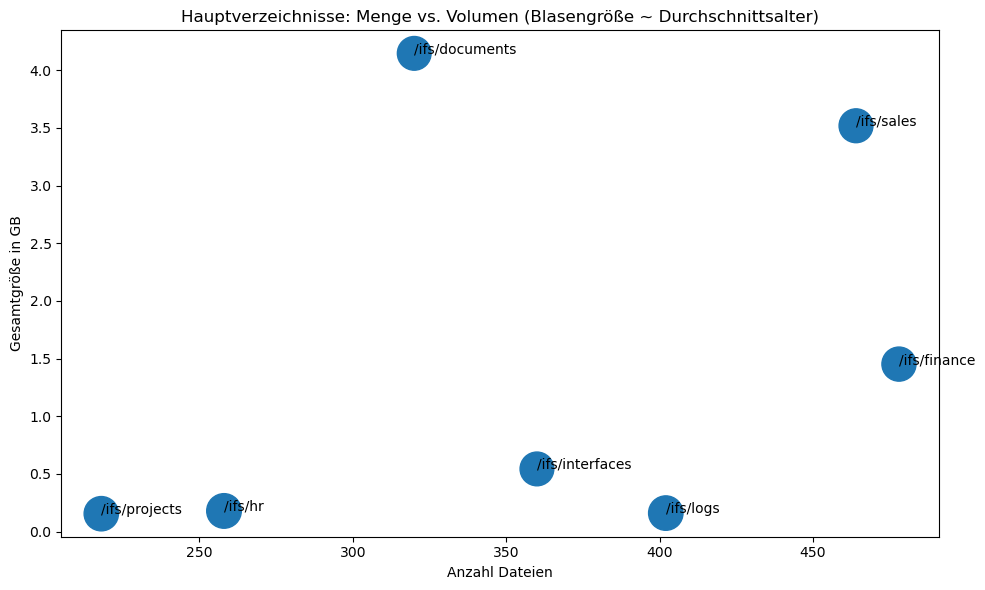

,root_dir,file_count,size_gb,avg_age_days
0,/ifs/documents,320,4.146125,1766.181250
6,/ifs/sales,464,3.518334,1783.015086
1,/ifs/finance,478,1.451941,1807.186192
3,/ifs/interfaces,360,0.543155,1770.788889
2,/ifs/hr,258,0.178815,1861.418605
4,/ifs/logs,402,0.160267,1843.997512
5,/ifs/projects,218,0.154904,1830.821101


In [12]:

bubble_df = (
    df.groupby("root_dir")
      .agg(
          file_count=("Name", "count"),
          size_gb=("size_gb", "sum"),
          avg_age_days=("age_days", "mean"),
      )
      .reset_index()
)

plt.figure(figsize=(10, 6))
plt.scatter(
    bubble_df["file_count"],
    bubble_df["size_gb"],
    s=bubble_df["avg_age_days"] / 3,
)
for _, row in bubble_df.iterrows():
    plt.annotate(row["root_dir"], (row["file_count"], row["size_gb"]))
plt.xlabel("Anzahl Dateien")
plt.ylabel("Gesamtgröße in GB")
plt.title("Hauptverzeichnisse: Menge vs. Volumen (Blasengröße ~ Durchschnittsalter)")
plt.tight_layout()
plt.show()

display(bubble_df.sort_values("size_gb", ascending=False))



**Interpretation:**  
Diese Grafik verdichtet drei Perspektiven in einer Sicht:
- **X-Achse:** Dateimenge
- **Y-Achse:** Speicherverbrauch
- **Blasengröße:** durchschnittliches Alter

Sie eignet sich gut für Besprechungen mit Entscheidungsträgern, sollte aber auf wenige, aggregierte Bereiche beschränkt bleiben.


## 10) Auffälligkeiten / Handlungsansätze

In [13]:

largest_files = df.nlargest(15, "Size")[["Name", "Path", "size_mb", "MRMod_Tme"]].copy()
largest_files["size_mb"] = largest_files["size_mb"].round(2)

oldest_files = df.sort_values("MRMod_Tme").head(15)[["Name", "Path", "size_mb", "MRMod_Tme"]].copy()
oldest_files["size_mb"] = oldest_files["size_mb"].round(2)

display(Markdown("### Größte Dateien"))
display(largest_files)

display(Markdown("### Älteste Dateien nach Änderungsdatum"))
display(oldest_files)


### Größte Dateien

,Name,Path,size_mb,MRMod_Tme
2454,file_02454.docx,/ifs/documents/archive/file_02454.docx,2499.35,2023-11-15 01:30:32
1144,file_01144.pdf,/ifs/sales/broker/file_01144.pdf,1403.42,2023-11-14 10:13:11
146,file_00146.docx,/ifs/documents/board/file_00146.docx,831.19,2018-05-13 21:05:25
504,file_00504.csv,/ifs/sales/daily/file_00504.csv,334.48,2019-06-23 11:16:52
1532,file_01532.pdf,/ifs/sales/archive/file_01532.pdf,307.30,2016-07-23 14:00:37
286,file_00286.docx,/ifs/documents/board/file_00286.docx,295.00,2020-03-18 08:52:29
1444,file_01444.csv,/ifs/sales/archive/file_01444.csv,284.49,2019-04-08 23:27:34
352,file_00352.txt,/ifs/finance/reports/file_00352.txt,280.46,2021-02-27 04:33:43
1077,file_01077.pdf,/ifs/sales/weekly/file_01077.pdf,214.20,2025-08-15 02:02:13
71,file_00071.pdf,/ifs/sales/daily/file_00071.pdf,196.77,2021-01-31 13:14:58


### Älteste Dateien nach Änderungsdatum

,Name,Path,size_mb,MRMod_Tme
451,file_00451.xlsx,/ifs/finance/monthly/file_00451.xlsx,0.51,2016-03-28 15:21:55
2286,file_02286.pdf,/ifs/documents/archive/file_02286.pdf,8.15,2016-03-28 23:24:31
64,file_00064.csv,/ifs/logs/system/file_00064.csv,0.02,2016-04-01 21:32:42
497,file_00497.csv,/ifs/interfaces/inbound/file_00497.csv,0.65,2016-04-03 06:57:46
74,file_00074.log,/ifs/logs/batch/file_00074.log,0.01,2016-04-04 18:06:50
476,file_00476.docx,/ifs/documents/policies/file_00476.docx,0.22,2016-04-05 06:46:05
595,file_00595.xlsx,/ifs/finance/exports/file_00595.xlsx,0.53,2016-04-06 17:55:25
2207,file_02207.csv,/ifs/projects/archive/file_02207.csv,0.18,2016-04-12 16:22:57
1788,file_01788.txt,/ifs/finance/exports/file_01788.txt,4.34,2016-04-12 19:57:05
2447,file_02447.txt,/ifs/interfaces/inbound/file_02447.txt,1.86,2016-04-13 00:41:31



**Mögliche managementtaugliche Schlussfolgerungen:**
1. Der Speicherverbrauch konzentriert sich auf wenige Hauptverzeichnisse.
2. Teilbereiche weisen einen hohen Altbestandsanteil auf.
3. Bestimmte Dateitypen dominieren Bestand oder Volumen.
4. Es lassen sich konkrete Kandidaten für Archivierungs- oder Bereinigungsprüfungen identifizieren.

Wichtig:  
Aus den Grafiken sollten **keine automatischen Löschentscheidungen** abgeleitet werden.  
Sie dienen zunächst als **Orientierungs- und Priorisierungshilfe**.


## 11) Umstellung von Dummy-Daten auf echte Scan-Daten

In [14]:

# Beispiel: So könnte später Deine echte CSV eingelesen werden
# df = pd.read_csv("ifs_scan.csv", sep=";", encoding="utf-8")

# Danach dieselben Aufbereitungsschritte aus Abschnitt 2 erneut ausführen.
print("Notebook ist vorbereitet. Für echte Daten nur CSV-Einlesung aktivieren.")


Notebook ist vorbereitet. Für echte Daten nur CSV-Einlesung aktivieren.
